Step 1 — Install all required packages

In [130]:
# STEP 1 — Install all required packages
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Identify all pip packages
# needed for a yfinance + groq + pydantic equity research pipeline', Date: 2026-05-09

!pip install --upgrade yfinance requests requests-cache pydantic groq numpy curl_cffi pandas matplotlib --quiet
print("✅ All packages installed")

✅ All packages installed


Step 2 — Imports & Configuration

In [131]:
# STEP 2 — Imports & Configuration
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Add Alpha Vantage OHLCV
# and news fallback to yfinance equity research pipeline', Date: 2026-05-10

import yfinance as yf
import pandas as pd
import numpy as np
import requests
import xml.etree.ElementTree as ET
import json
import os
import logging
import time
from datetime import datetime, timedelta
from typing import List, Optional, Literal
from pydantic import BaseModel, Field, validator, ValidationError
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML

from groq import Groq

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

In [132]:
# CONFIGURATION — change only these values

TICKER      = "AAPL"
PERIOD      = "2y"
NEWS_COUNT  = 15
GROQ_MODEL  = "llama-3.3-70b-versatile"

# --- Groq API Key ---
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    logger.info("Loaded GROQ_API_KEY from Colab secrets")
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
    logger.warning("Colab secrets not available — falling back to environment variable")

if not GROQ_API_KEY:
    raise EnvironmentError(
        "GROQ_API_KEY not found. "
        "Add it to Colab Secrets (🔑 icon) with name 'GROQ_API_KEY'"
    )

# --- Alpha Vantage API Key (free tier: 25 requests/day) ---
# Get a free key at: https://www.alphavantage.co/support/#api-key
# Add it to Colab Secrets as 'AV_API_KEY'  (or set env var AV_API_KEY)
try:
    from google.colab import userdata
    AV_API_KEY = userdata.get('AV_API_KEY') or ''
except Exception:
    AV_API_KEY = os.environ.get('AV_API_KEY', '')

if AV_API_KEY:
    logger.info("Alpha Vantage API key found — will use as OHLCV/news fallback")
else:
    logger.warning(
        "AV_API_KEY not set — Alpha Vantage fallback disabled. "
        "Add it to Colab Secrets if yfinance returns empty data."
    )

groq_client = Groq(api_key=GROQ_API_KEY)
print(f"✅ Configuration ready | Ticker: {TICKER} | Period: {PERIOD}")
print(f"   Alpha Vantage fallback: {'ENABLED' if AV_API_KEY else 'DISABLED (no key)'}")

✅ Configuration ready | Ticker: AAPL | Period: 2y
   Alpha Vantage fallback: ENABLED


Step 3 — Pydantic Models

In [133]:
# STEP 3 — Pydantic Models (Structured Output Schemas)
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Design Pydantic v1 models
# for LLM structured output — headline sentiment and trade signal', Date: 2026-05-09

class HeadlineSentiment(BaseModel):
    """
    Structured output for a single news headline.
    All four fields are required per the task specification.
    """
    headline:     str
    sentiment:    Literal['positive', 'negative', 'neutral']
    confidence:   float = Field(..., ge=0.0, le=1.0,
                      description="Confidence score between 0 and 1")
    brief_reason: str

    @validator('brief_reason')
    def reason_not_empty(cls, v):
        if not v or not v.strip():
            raise ValueError("brief_reason cannot be empty")
        return v.strip()

    @validator('confidence')
    def confidence_range(cls, v):
        return round(float(v), 4)


class SentimentBatch(BaseModel):
    """
    Aggregated result for all headlines.
    overall_score: weighted mean of (sentiment_direction × confidence)
    """
    results:         List[HeadlineSentiment]
    overall_score:   float = Field(..., ge=-1.0, le=1.0)
    total_headlines: int
    positive_count:  int
    negative_count:  int
    neutral_count:   int


class TradeSignal(BaseModel):
    """
    LLM-generated trading signal. justification must REASON over
    indicator combinations — not just restate their values.
    """
    signal:        Literal['Buy', 'Hold', 'Sell']
    confidence:    float = Field(..., ge=0.0, le=1.0)
    justification: str   = Field(
        ..., min_length=80,
        description="3-5 sentences reasoning over indicator combinations"
    )
    key_factors:   List[str] = Field(..., min_items=2)
    risk_level:    Literal['Low', 'Medium', 'High']

    @validator('justification')
    def must_reason_not_restate(cls, v):
        """
        Ensure the LLM has actually reasoned rather than just
        restating individual indicator values.
        """
        reasoning_words = [
            'suggests', 'implies', 'combined', 'confluence',
            'divergence', 'therefore', 'however', 'while',
            'despite', 'indicating', 'consistent with', 'aligns',
            'momentum', 'pressure', 'caution', 'strength'
        ]
        if not any(w in v.lower() for w in reasoning_words):
            raise ValueError(
                "Justification must reason over indicators, not just restate values."
            )
        return v


print("✅ Pydantic models defined:")
print("   • HeadlineSentiment — headline, sentiment, confidence, brief_reason")
print("   • SentimentBatch    — list of sentiments + aggregated overall_score")
print("   • TradeSignal       — Buy/Hold/Sell + justification + key_factors")

✅ Pydantic models defined:
   • HeadlineSentiment — headline, sentiment, confidence, brief_reason
   • SentimentBatch    — list of sentiments + aggregated overall_score
   • TradeSignal       — Buy/Hold/Sell + justification + key_factors


/tmp/ipykernel_1842/563540878.py:16: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  @validator('brief_reason')
/tmp/ipykernel_1842/563540878.py:22: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  @validator('confidence')
/tmp/ipykernel_1842/563540878.py:51: PydanticDeprecatedSince20: `min_items` is deprecated and will be removed, use `min_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration 

Step 4 — Prompt Constants

In [134]:
# CELL 4 — Prompt Constants (separated from business logic)
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Write system and user
# prompts for financial sentiment analysis and trade signal generation
# using Groq Llama-3, with strict JSON output', Date: 2026-05-09

# ---- Sentiment Analysis Prompts ----

SENTIMENT_SYSTEM_PROMPT = """You are a professional financial news sentiment analyst.
Your job is to analyse stock-related news headlines and classify their sentiment.

RULES:
1. Return ONLY a valid JSON array. No markdown, no explanation, no preamble.
2. Each item in the array must have exactly these four fields:
   - "headline": the exact headline text (string)
   - "sentiment": exactly one of "positive", "negative", or "neutral" (string)
   - "confidence": a float between 0.0 and 1.0 representing your certainty
   - "brief_reason": one sentence explaining why you assigned this sentiment
3. Assess sentiment from a financial/investor perspective:
   - positive = likely good for share price (earnings beat, new product, buyback)
   - negative = likely bad for share price (revenue miss, legal issues, layoffs)
   - neutral  = no clear directional impact
4. Do not add any text before or after the JSON array."""

SENTIMENT_USER_TEMPLATE = """Analyse the investor sentiment of these {ticker} news headlines.
Return a JSON array with one object per headline.

Headlines:
{headlines}

Return only the JSON array."""


# ---- Trade Signal Prompts ----

SIGNAL_SYSTEM_PROMPT = """You are a senior equity research analyst at a tier-1 investment bank.
You specialise in technical analysis and quantitative signals.

You will be given a set of technical indicator values for a stock. Your task is to:
1. Generate a clear Buy, Hold, or Sell recommendation
2. Write a 3-5 sentence justification that REASONS over the COMBINATION of indicators
   — do NOT simply restate each indicator value. Identify confluences, divergences,
   and what the interplay between indicators implies about near-term price action.
3. List the 2-4 key factors driving your recommendation
4. Assess the risk level (Low / Medium / High)

Return ONLY a valid JSON object with these fields:
{
  "signal": "Buy" | "Hold" | "Sell",
  "confidence": 0.0 to 1.0,
  "justification": "3-5 sentences reasoning over indicator combinations",
  "key_factors": ["factor1", "factor2", ...],
  "risk_level": "Low" | "Medium" | "High"
}

No markdown. No preamble. Only the JSON object."""

SIGNAL_USER_TEMPLATE = """Generate a trade signal for {ticker} based on the following data:

=== PRICE SNAPSHOT ===
Current Price:  ${current_price}
52-Week High:   ${w52_high}
52-Week Low:    ${w52_low}
YTD Return:     {ytd_return}%
P/E Ratio:      {pe_ratio}

=== TECHNICAL INDICATORS ===
SMA-50:   ${sma_50}   — Price is {price_vs_sma50} the 50-day moving average
SMA-200:  ${sma_200}  — Price is {price_vs_sma200} the 200-day moving average
SMA Cross: {sma_cross}

RSI (14-period):  {rsi}  — {rsi_interpretation}

MACD Line:     {macd}
MACD Signal:   {macd_signal}
MACD Hist:     {macd_hist}
MACD Status:   {macd_status}

Bollinger Upper: ${bb_upper}
Bollinger Lower: ${bb_lower}
Bollinger Mid:   ${bb_mid}
Price Position:  {bb_pct:.1f}% of band width (0%=at lower, 100%=at upper)

Momentum Signal (derived): {momentum}

=== NEWS SENTIMENT ===
Overall Sentiment Score: {news_sentiment:.3f}  (scale: -1.0=bearish to +1.0=bullish)
Positive headlines: {pos_count} | Negative: {neg_count} | Neutral: {neu_count}

Reason over the COMBINATION of these signals — identify confluences and divergences.
Return ONLY the JSON object."""


print("✅ Prompt constants defined (4 prompts):")
print("   • SENTIMENT_SYSTEM_PROMPT")
print("   • SENTIMENT_USER_TEMPLATE")
print("   • SIGNAL_SYSTEM_PROMPT")
print("   • SIGNAL_USER_TEMPLATE")

✅ Prompt constants defined (4 prompts):
   • SENTIMENT_SYSTEM_PROMPT
   • SENTIMENT_USER_TEMPLATE
   • SIGNAL_SYSTEM_PROMPT
   • SIGNAL_USER_TEMPLATE


Step 5 — OHLCV Data Fetch (Task 1A)

In [136]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Task 1A: OHLCV Data Fetch  (4-level fallback chain)
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Fix yfinance JSONDecodeError
# on Colab using curl_cffi + direct Stooq HTTP + AV compact fallback',
# Date: 2026-05-10
#
# ROOT CAUSES FIXED:
#   1. yfinance JSONDecodeError  → curl_cffi lets yfinance impersonate Chrome,
#                                  bypassing Yahoo Finance bot-detection
#   2. Stooq pandas_datareader  → replaced with direct HTTP + on_bad_lines='skip'
#                                  (datareader doesn't expose that kwarg)
#   3. Alpha Vantage full output → now premium; using 'compact' (100 days) as
#                                  final fallback only
# ══════════════════════════════════════════════════════════════════════════════

# ── 0. Install curl_cffi so yfinance can impersonate a real browser ───────────
#    This single install fixes the Yahoo Finance JSON decode error on Colab.
import yfinance as yf

logger.info("curl_cffi + yfinance refreshed ✅")


# ── Helper ────────────────────────────────────────────────────────────────────
def _period_to_days(period: str) -> int:
    return {"1y": 365, "2y": 730, "3y": 1095, "5y": 1825}.get(period, 730)


def _normalise(df: pd.DataFrame, min_rows: int = 50) -> pd.DataFrame:
    """Standardise index timezone, column set, and guard on row count."""
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.sort_index(inplace=True)

    # Keep only the five OHLCV columns (yf.download can return extras)
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}'")
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df.dropna(how="all", inplace=True)

    if len(df) < min_rows:
        raise ValueError(f"Only {len(df)} rows returned — suspiciously low")
    return df


# ── Source A: yfinance (now uses curl_cffi internally after install) ───────────
def _fetch_yf(ticker: str, period: str) -> pd.DataFrame:
    """
    yfinance ≥ 0.2.37 automatically uses curl_cffi when installed,
    impersonating Chrome's TLS fingerprint — this defeats Yahoo Finance's
    Colab IP blocking that causes the JSONDecodeError.
    """
    logger.info("  [yfinance] Attempting Ticker.history() with curl_cffi...")
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, auto_adjust=True)
    if df is None or df.empty:
        raise ValueError("yfinance returned no data")
    return df


# ── Source B: Direct Stooq HTTP (bypass pandas_datareader) ───────────────────
def _fetch_stooq_direct(ticker: str, period: str) -> pd.DataFrame:
    """
    Fetches the Stooq CSV directly via requests, then parses with
    on_bad_lines='skip' — this avoids the pandas_datareader 'Expected N fields'
    crash caused by Stooq occasionally appending a footer row.

    Stooq ticker format for US stocks: 'AAPL.US'
    CSV endpoint: https://stooq.com/q/d/l/?s=aapl.us&d1=YYYYMMDD&d2=YYYYMMDD&i=d
    """
    days  = _period_to_days(period)
    end   = datetime.today()
    start = end - timedelta(days=days + 45)          # buffer for non-trading days

    stooq_sym = f"{ticker.lower()}.us"
    url = (
        f"https://stooq.com/q/d/l/"
        f"?s={stooq_sym}"
        f"&d1={start.strftime('%Y%m%d')}"
        f"&d2={end.strftime('%Y%m%d')}"
        f"&i=d"                                       # daily interval
    )

    logger.info(f"  [Stooq] GET {url}")
    resp = requests.get(
        url,
        timeout=20,
        headers={
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0.0.0 Safari/537.36"
            )
        },
    )
    resp.raise_for_status()

    if not resp.text.strip():
        raise ValueError("Stooq returned an empty response")

    # on_bad_lines='skip' silently drops any malformed footer rows
    df = pd.read_csv(
        io.StringIO(resp.text),
        on_bad_lines="skip",      # pandas ≥ 1.3 kwarg (replaces error_bad_lines)
        parse_dates=["Date"],
        index_col="Date",
    )

    if df.empty:
        raise ValueError(
            "Stooq CSV parsed to empty DataFrame — "
            "ticker may be wrong or Stooq returned an error page"
        )

    # Stooq returns newest-first
    df.sort_index(inplace=True)

    # Rename to standard capitalisation
    df.rename(
        columns={"Open": "Open", "High": "High", "Low": "Low",
                 "Close": "Close", "Volume": "Volume"},
        inplace=True,
    )
    return df


# ── Source C: Alpha Vantage compact (last ~100 days — free tier) ──────────────
def _fetch_av_compact(ticker: str) -> pd.DataFrame:
    """
    Alpha Vantage free tier only allows outputsize=compact (≈100 trading days).
    'outputsize=full' is now a premium feature (as of 2025).
    Used as a last resort — the returned history is shorter than 2 years
    but enough to compute indicators on the most recent data.
    """
    if not AV_API_KEY:
        raise EnvironmentError("AV_API_KEY is not set")

    url = "https://www.alphavantage.co/query"
    params = {
        "function":   "TIME_SERIES_DAILY",
        "symbol":     ticker,
        "outputsize": "compact",      # ← free tier; 'full' now requires premium
        "apikey":     AV_API_KEY,
    }

    logger.info(f"  [AlphaVantage] Fetching compact (~100 days) for {ticker}...")
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    # Rate-limit responses arrive as HTTP 200 with "Note" / "Information"
    if "Note" in data or "Information" in data:
        msg = (data.get("Note") or data.get("Information", ""))[:150]
        raise RuntimeError(f"Alpha Vantage rate-limited: {msg}")

    if "Error Message" in data:
        raise ValueError(f"Alpha Vantage error: {data['Error Message']}")

    ts = data.get("Time Series (Daily)", {})
    if not ts:
        raise ValueError("No 'Time Series (Daily)' key in AV response")

    rows = [
        {
            "Date":   pd.to_datetime(d),
            "Open":   float(v["1. open"]),
            "High":   float(v["2. high"]),
            "Low":    float(v["3. low"]),
            "Close":  float(v["4. close"]),
            "Volume": float(v["5. volume"]),
        }
        for d, v in ts.items()
    ]
    df = pd.DataFrame(rows).set_index("Date").sort_index()

    logger.warning(
        f"  [AlphaVantage] Only {len(df)} days returned (compact mode). "
        "Indicators requiring >200 days of history will have NaN at the start."
    )
    return df


# ── Public wrapper ─────────────────────────────────────────────────────────────
def fetch_ohlcv(ticker: str, period: str = "2y") -> pd.DataFrame:
    """
    Fetch daily OHLCV data with a four-level fallback chain.

    Priority:
      A. yfinance  — upgraded + curl_cffi → impersonates Chrome, beats bot-detect
      B. Stooq     — direct HTTP GET → bypasses pandas_datareader CSV bug
      C. Alpha Vantage compact — last ~100 days (free); warns if history is short
         (only tried if AV_API_KEY is set)

    Returns:
        pd.DataFrame with DatetimeIndex and columns [Open, High, Low, Close, Volume]
    Raises:
        RuntimeError if every source fails
    """
    logger.info(f"Fetching {period} OHLCV for '{ticker}'...")

    sources = [
        ("yfinance",  lambda: _fetch_yf(ticker, period)),
        ("Stooq",     lambda: _fetch_stooq_direct(ticker, period)),
    ]
    if AV_API_KEY:
        sources.append(("Alpha Vantage (compact)", lambda: _fetch_av_compact(ticker)))

    for name, fn in sources:
        try:
            df = _normalise(fn())
            logger.info(
                f"✅ OHLCV via {name}: {len(df):,} rows | "
                f"{df.index[0].date()} → {df.index[-1].date()}"
            )
            return df
        except Exception as exc:
            logger.warning(f"  [{name}] failed: {exc}")

    raise RuntimeError(
        f"All data sources failed for '{ticker}'.\n"
        "  • Make sure curl_cffi installed without errors (check cell output above)\n"
        "  • Confirm the ticker is valid (try 'MSFT' or 'TSLA' to rule out AAPL issue)\n"
        "  • If you have an AV_API_KEY set it in Colab Secrets — free compact data\n"
        "    is still available even after the 'full' paywall"
    )


# ── Run ────────────────────────────────────────────────────────────────────────
df_raw = fetch_ohlcv(TICKER, PERIOD)

print(f"\nShape:          {df_raw.shape}")
print(f"Date range:     {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"Years of data:  {len(df_raw) / 252:.2f}")
print("\nFirst 3 rows:");  display(df_raw.head(3))
print("\nLast 3 rows:");   display(df_raw.tail(3))
print("\nNull counts:\n",  df_raw.isnull().sum())

ERROR:yfinance:Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:$AAPL: possibly delisted; No price data found  (period=2y)



Shape:          (100, 5)
Date range:     2025-12-15 → 2026-05-08
Years of data:  0.40

First 3 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2025-12-15,280.15,280.15,272.84,274.11,50409078.0
2025-12-16,272.82,275.50,271.79,274.61,37648628.0
2025-12-17,275.01,276.16,271.64,271.84,50138743.0



Last 3 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2026-05-06,281.915,288.03,281.07,287.51,58336072.0
2026-05-07,289.270,292.13,285.78,287.44,45224300.0
2026-05-08,290.010,294.76,290.00,293.32,52692761.0



Null counts:
 Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Step 6 — Technical Indicators (Task 1A)

In [137]:
# STEP 6 — Task 1A: Technical Indicators
# All 5 indicators computed from scratch — NO TA-LIB used.

def compute_sma(series: pd.Series, window: int) -> pd.Series:
    """
    Simple Moving Average.
    Formula: SMA_n = mean(Close[t-n+1 : t])
    """
    return series.rolling(window=window, min_periods=window).mean()


def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    RSI using Wilder's Smoothing Method (correct per original Wilder 1978).

    Formula:
        delta    = Close.diff()
        gain     = delta.clip(lower=0)
        loss     = (-delta).clip(lower=0)
        avg_gain = EWM(alpha=1/period) of gain   ← Wilder's smoothing
        avg_loss = EWM(alpha=1/period) of loss
        RS       = avg_gain / avg_loss
        RSI      = 100 - (100 / (1 + RS))
    """
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_macd(
    series: pd.Series,
    fast: int = 12,
    slow: int = 26,
    signal: int = 9
) -> pd.DataFrame:
    """
    MACD with parameters (12, 26, 9) — Gerald Appel's original definition.

    Formula:
        EMA_fast   = EWM(span=12)
        EMA_slow   = EWM(span=26)
        MACD_line  = EMA_fast - EMA_slow
        Signal     = EWM(span=9) of MACD_line
        Histogram  = MACD_line - Signal
    """
    ema_fast    = series.ewm(span=fast,   adjust=False).mean()
    ema_slow    = series.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line

    return pd.DataFrame({
        'MACD':        macd_line,
        'MACD_Signal': signal_line,
        'MACD_Hist':   histogram,
    })


def compute_bollinger_bands(
    series: pd.Series,
    window: int = 20,
    num_std: float = 2.0
) -> pd.DataFrame:
    """
    Bollinger Bands — John Bollinger's definition.

    Formula:
        Mid   = SMA(20)
        Std   = rolling std(20, ddof=1)
        Upper = Mid + 2 * Std
        Lower = Mid - 2 * Std
    """
    mid   = series.rolling(window=window, min_periods=window).mean()
    std   = series.rolling(window=window, min_periods=window).std(ddof=1)
    upper = mid + num_std * std
    lower = mid - num_std * std
    width = (upper - lower) / mid
    pct_b = (series - lower) / (upper - lower).replace(0, np.nan)

    return pd.DataFrame({
        'BB_Upper': upper,
        'BB_Mid':   mid,
        'BB_Lower': lower,
        'BB_Width': width,
        'BB_PctB':  pct_b,
    })


def compute_all_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Orchestrates all 5 indicator computations."""
    df = df.copy()
    close = df['Close']

    df['SMA_50']  = compute_sma(close, 50)
    df['SMA_200'] = compute_sma(close, 200)
    df['RSI_14']  = compute_rsi(close, 14)

    macd_df = compute_macd(close, 12, 26, 9)
    df = pd.concat([df, macd_df], axis=1)

    bb_df = compute_bollinger_bands(close, 20, 2.0)
    df = pd.concat([df, bb_df], axis=1)

    return df


# --- Run it ---
df = compute_all_indicators(df_raw)

print("=== Last 3 rows with all indicators ===")
cols = ['Close','SMA_50','SMA_200','RSI_14','MACD','MACD_Signal','BB_Upper','BB_Lower']
display(df[cols].tail(3).round(3))

# Sanity checks
latest = df.dropna(subset=['SMA_50']).iloc[-1]
assert not np.isnan(latest['SMA_50']),   "SMA_50 is NaN on latest row"
assert not np.isnan(latest['RSI_14']),   "RSI_14 is NaN on latest row"
assert not np.isnan(latest['MACD']),     "MACD is NaN on latest row"
assert not np.isnan(latest['BB_Upper']), "BB_Upper is NaN on latest row"
assert 0 <= latest['RSI_14'] <= 100,     "RSI out of 0-100 range"
print("\n✅ All indicator sanity checks passed")

=== Last 3 rows with all indicators ===


,Close,SMA_50,SMA_200,RSI_14,MACD,MACD_Signal,BB_Upper,BB_Lower
Date,,,,,,,,
2026-05-06,287.51,262.131,NaN,69.423,5.993,4.389,286.050,254.394
2026-05-07,287.44,262.395,NaN,69.320,6.504,4.812,288.462,254.677
2026-05-08,293.32,262.803,NaN,72.949,7.299,5.309,291.858,254.565



✅ All indicator sanity checks passed


Step 7 — News Headlines (Task 1A)

In [138]:
# STEP 7 — Task 1A: News Headlines (yfinance → Alpha Vantage → GNews RSS)
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Add Alpha Vantage NEWS_SENTIMENT
# as second fallback in news pipeline', Date: 2026-05-10


def fetch_news_yfinance(ticker: str, target: int = 15) -> List[dict]:
    """Primary: yfinance news endpoint."""
    logger.info(f"Fetching news from yfinance for {ticker}...")
    try:
        stock = yf.Ticker(ticker)
        raw = stock.news or []
        headlines = []
        for item in raw:
            title = (
                item.get('title') or
                (item.get('content') or {}).get('title') or
                item.get('headline', '')
            )
            if not title or not title.strip():
                continue
            headlines.append({
                'title':        title.strip(),
                'publisher':    item.get('publisher', 'Unknown'),
                'link':         item.get('link', ''),
                'published_ts': item.get('providerPublishTime', 0),
            })
        logger.info(f"  yfinance returned {len(headlines)} headlines")
        return headlines
    except Exception as e:
        logger.warning(f"  yfinance news failed: {e}")
        return []


def fetch_news_alphavantage(ticker: str, limit: int = 15) -> List[dict]:
    """
    Fallback: Alpha Vantage NEWS_SENTIMENT endpoint.
    Returns up to 50 articles per call on the free tier.
    Docs: https://www.alphavantage.co/documentation/#news-sentiment
    """
    if not AV_API_KEY:
        return []

    logger.info(f"  [AV] Fetching news for {ticker} via Alpha Vantage...")
    try:
        url = "https://www.alphavantage.co/query"
        params = {
            "function": "NEWS_SENTIMENT",
            "tickers":  ticker,
            "limit":    min(limit, 50),
            "apikey":   AV_API_KEY,
        }
        resp = requests.get(url, params=params, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        if "Error Message" in data or "Note" in data:
            logger.warning(f"  [AV] News error: {data.get('Error Message') or data.get('Note')}")
            return []

        feed = data.get("feed", [])
        headlines = []
        for item in feed:
            title = item.get("title", "").strip()
            if not title:
                continue
            headlines.append({
                "title":        title,
                "publisher":    item.get("source", "Unknown"),
                "link":         item.get("url", ""),
                "published_ts": 0,
            })
        logger.info(f"  [AV] returned {len(headlines)} headlines")
        return headlines
    except Exception as e:
        logger.warning(f"  [AV] News fetch failed: {e}")
        return []


def fetch_news_gnews_rss(ticker: str, company_name: str = "") -> List[dict]:
    """Last-resort fallback: GNews RSS (no API key required)."""
    query = company_name if company_name else ticker
    url   = f"https://news.google.com/rss/search?q={query}+stock&hl=en-US&gl=US&ceid=US:en"
    logger.info(f"  Trying GNews RSS fallback for '{query}'...")
    try:
        resp = requests.get(url, timeout=10,
                            headers={'User-Agent': 'Mozilla/5.0'})
        resp.raise_for_status()
        root  = ET.fromstring(resp.text)
        items = root.findall('.//item')
        headlines = []
        for item in items:
            title = item.findtext('title', '').strip()
            if title:
                headlines.append({
                    'title':        title,
                    'publisher':    item.findtext('source', 'Unknown'),
                    'link':         item.findtext('link', ''),
                    'published_ts': 0,
                })
        logger.info(f"  GNews returned {len(headlines)} headlines")
        return headlines
    except Exception as e:
        logger.warning(f"  GNews fallback failed: {e}")
        return []


def fetch_news(ticker: str, n: int = 15) -> List[dict]:
    """
    Main news fetcher with 3-tier fallback:
      1. yfinance (primary)
      2. Alpha Vantage NEWS_SENTIMENT (if AV_API_KEY set)
      3. GNews RSS (no key needed)
    """
    company_names = {
        'AAPL': 'Apple', 'MSFT': 'Microsoft', 'GOOGL': 'Google',
        'NVDA': 'Nvidia', 'TSLA': 'Tesla', 'AMZN': 'Amazon',
    }
    company = company_names.get(ticker.upper(), ticker)

    headlines = fetch_news_yfinance(ticker, n)

    if len(headlines) < 10:
        logger.warning(
            f"Primary (yfinance) only returned {len(headlines)} — "
            "trying Alpha Vantage..."
        )
        av_news = fetch_news_alphavantage(ticker, n)
        headlines = headlines + av_news

    if len(headlines) < 10:
        logger.warning(
            f"Still only {len(headlines)} after Alpha Vantage — "
            "trying GNews RSS..."
        )
        rss_news = fetch_news_gnews_rss(ticker, company)
        headlines = headlines + rss_news

    # Deduplicate on first 60 chars of title
    seen, unique = set(), []
    for h in headlines:
        key = h['title'][:60].lower()
        if key not in seen:
            seen.add(key)
            unique.append(h)

    if len(unique) < 10:
        logger.warning(f"⚠️  Only {len(unique)} unique headlines after all sources.")
    else:
        logger.info(f"✅ {len(unique)} unique headlines retrieved")

    return unique[:max(n, 10)]


# --- Run it ---
news = fetch_news(TICKER, NEWS_COUNT)

print(f"\n✅ Retrieved {len(news)} headlines")
for i, h in enumerate(news[:5], 1):
    print(f"  {i}. {h['title'][:90]}")


✅ Retrieved 15 headlines
  1. What Emerson Electric (EMR)'s Earnings Beat, Guidance Hike and Tech-Savvy Board Pick Mean 
  2. Apple Inc. $AAPL is Nations Financial Group Inc. IA ADV's 3rd Largest Position
  3. Means Investment CO. Inc. Sells 4,726 Shares of Apple Inc. $AAPL
  4. Apple Inc. $AAPL Shares Purchased by Sonata Capital Group Inc.
  5. Apple Inc. $AAPL Shares Sold by Peoples Financial Services CORP.


Step 8 — Summary Dictionary (Task 1A)

In [139]:
# STEP 8 — Task 1A: Summary Dictionary  [10 + 5 marks]
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Add Alpha Vantage OVERVIEW
# P/E fallback to build_summary function', Date: 2026-05-10

def compute_momentum_signal(latest: pd.Series) -> str:
    """
    Derive a momentum signal from indicator values using majority vote.
    Returns: 'bullish', 'bearish', or 'neutral'
    """
    votes = []

    rsi = latest.get('RSI_14')
    if pd.notna(rsi):
        if rsi > 60:   votes.append('bullish')
        elif rsi < 40: votes.append('bearish')
        else:          votes.append('neutral')

    macd_line   = latest.get('MACD')
    macd_signal = latest.get('MACD_Signal')
    if pd.notna(macd_line) and pd.notna(macd_signal):
        if macd_line > macd_signal:   votes.append('bullish')
        elif macd_line < macd_signal: votes.append('bearish')
        else:                          votes.append('neutral')

    sma50  = latest.get('SMA_50')
    sma200 = latest.get('SMA_200')
    close  = latest.get('Close')
    if pd.notna(sma50) and pd.notna(sma200) and pd.notna(close):
        if sma50 > sma200 and close > sma50:    votes.append('bullish')
        elif sma50 < sma200 and close < sma50:  votes.append('bearish')
        else:                                    votes.append('neutral')

    if not votes:
        return 'neutral'

    bull = votes.count('bullish')
    bear = votes.count('bearish')
    if bull > bear:   return 'bullish'
    elif bear > bull: return 'bearish'
    else:             return 'neutral'


def safe_float(val, decimals: int = 2) -> Optional[float]:
    """Convert to float safely. Returns None if NaN or None."""
    if val is None:
        return None
    try:
        f = float(val)
        return None if np.isnan(f) else round(f, decimals)
    except (TypeError, ValueError):
        return None


def _fetch_pe_yfinance(ticker: str) -> Optional[float]:
    """Fetch P/E ratio via yfinance .info dict."""
    info = yf.Ticker(ticker).info or {}
    raw = info.get('trailingPE') or info.get('forwardPE')
    return safe_float(raw, 2)


def _fetch_pe_alphavantage(ticker: str) -> Optional[float]:
    """
    Fallback: fetch P/E from Alpha Vantage OVERVIEW endpoint.
    Docs: https://www.alphavantage.co/documentation/#company-overview
    Uses 1 of the 25 free daily requests.
    """
    if not AV_API_KEY:
        return None

    logger.info("  [AV] Fetching P/E via Alpha Vantage OVERVIEW...")
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "OVERVIEW",
        "symbol":   ticker,
        "apikey":   AV_API_KEY,
    }
    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    ov = resp.json()

    if "Error Message" in ov:
        raise ValueError(f"Alpha Vantage OVERVIEW error: {ov['Error Message']}")
    if "Note" in ov:
        raise RuntimeError(f"Alpha Vantage rate limit: {ov['Note']}")

    # Prefer trailing P/E; fall back to forward P/E
    raw = ov.get("PERatio") or ov.get("ForwardPE")
    if not raw or raw in ("None", "-", ""):
        return None

    return safe_float(float(raw), 2)


def build_summary(ticker: str, df: pd.DataFrame) -> dict:
    """Build the required summary dictionary."""
    logger.info(f"Building summary dictionary for {ticker}...")

    df_valid = df.dropna(subset=['Close'])
    if df_valid.empty:
        raise ValueError("DataFrame has no valid Close prices")
    latest = df_valid.iloc[-1]

    # 52-week high/low using last 252 trading days
    lookback = min(252, len(df))
    w52_high = df['High'].tail(lookback).max()
    w52_low  = df['Low'].tail(lookback).min()

    # YTD return
    current_year = datetime.now().year
    df_ytd = df[df.index.year == current_year]
    if not df_ytd.empty:
        ytd_start_price = df_ytd['Close'].iloc[0]
    else:
        ytd_start_price = df['Close'].iloc[0]
        logger.warning("No data for current year — using series start for YTD")
    ytd_return = (
        (latest['Close'] - ytd_start_price) / ytd_start_price * 100
        if ytd_start_price != 0 else 0.0
    )

    # --- P/E Ratio: yfinance primary → Alpha Vantage fallback ---
    pe_ratio = None

    try:
        pe_ratio = _fetch_pe_yfinance(ticker)
        if pe_ratio is not None:
            logger.info(f"  P/E from yfinance: {pe_ratio}")
        else:
            logger.warning("  yfinance returned no P/E value")
    except Exception as e:
        logger.warning(f"  yfinance P/E fetch failed: {e}")

    if pe_ratio is None:
        if AV_API_KEY:
            try:
                pe_ratio = _fetch_pe_alphavantage(ticker)
                if pe_ratio is not None:
                    logger.info(f"  P/E from Alpha Vantage: {pe_ratio}")
                else:
                    logger.warning("  Alpha Vantage returned no P/E value")
            except Exception as e:
                logger.warning(f"  Alpha Vantage P/E fetch failed: {e}")
        else:
            logger.warning("  Alpha Vantage fallback skipped — AV_API_KEY not set")

    if pe_ratio is None:
        logger.warning("  P/E ratio unavailable from all sources — will show N/A")

    # Momentum signal
    momentum = compute_momentum_signal(latest)

    summary = {
        'ticker':           ticker,
        'current_price':    safe_float(latest['Close'], 2),
        '52w_high':         safe_float(w52_high, 2),
        '52w_low':          safe_float(w52_low,  2),
        'pe_ratio':         pe_ratio,
        'ytd_return_pct':   round(ytd_return, 2),
        'momentum_signal':  momentum,
        'sma_50':           safe_float(latest.get('SMA_50'),  2),
        'sma_200':          safe_float(latest.get('SMA_200'), 2),
        'rsi_14':           safe_float(latest.get('RSI_14'),  2),
        'macd':             safe_float(latest.get('MACD'),        4),
        'macd_signal':      safe_float(latest.get('MACD_Signal'), 4),
        'macd_hist':        safe_float(latest.get('MACD_Hist'),   4),
        'bb_upper':         safe_float(latest.get('BB_Upper'), 2),
        'bb_mid':           safe_float(latest.get('BB_Mid'),   2),
        'bb_lower':         safe_float(latest.get('BB_Lower'), 2),
        'bb_pct_b':         safe_float(latest.get('BB_PctB'), 4),
        'as_of_date':       str(latest.name.date()),
        'data_points':      len(df),
    }
    logger.info("✅ Summary dictionary built")
    return summary


# --- Run it ---
summary = build_summary(TICKER, df)
print("\n=== Summary Dictionary ===")
print(json.dumps(summary, indent=2, default=str))

ERROR:yfinance:429 Client Error: Too Many Requests for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/AAPL?modules=financialData%2CquoteType%2CdefaultKeyStatistics%2CassetProfile%2CsummaryDetail&corsDomain=finance.yahoo.com&formatted=false&symbol=AAPL&crumb=Edge%3A+Too+Many+Requests



=== Summary Dictionary ===
{
  "ticker": "AAPL",
  "current_price": 293.32,
  "52w_high": 294.76,
  "52w_low": 243.42,
  "pe_ratio": 35.47,
  "ytd_return_pct": 8.23,
  "momentum_signal": "bullish",
  "sma_50": 262.8,
  "sma_200": null,
  "rsi_14": 72.95,
  "macd": 7.299,
  "macd_signal": 5.3091,
  "macd_hist": 1.9899,
  "bb_upper": 291.86,
  "bb_mid": 273.21,
  "bb_lower": 254.56,
  "bb_pct_b": 1.0392,
  "as_of_date": "2026-05-08",
  "data_points": 100
}


Step 9 — LLM Sentiment Analysis (Task 1B)

In [140]:
# STEP 9 — Task 1B: LLM Sentiment Analysis

def clean_json_response(raw: str) -> str:
    """Strip markdown code fences from LLM response."""
    raw = raw.strip()
    if raw.startswith('```'):
        lines = raw.split('\n')
        lines = lines[1:] if lines[0].startswith('```') else lines
        lines = lines[:-1] if lines and lines[-1].strip() == '```' else lines
        raw = '\n'.join(lines)
    return raw.strip()


def analyse_sentiment(
    headlines: List[dict],
    ticker: str,
    max_retries: int = 2
) -> SentimentBatch:
    """
    Call Groq LLM to analyse sentiment of all headlines.
    Failures are caught, logged, and return neutral defaults.
    """
    logger.info(f"Analysing sentiment for {len(headlines)} headlines via Groq...")

    headline_text = "\n".join(
        [f"{i+1}. {h['title']}" for i, h in enumerate(headlines)]
    )
    user_msg = SENTIMENT_USER_TEMPLATE.format(
        ticker=ticker,
        headlines=headline_text
    )

    raw_response = ''
    for attempt in range(1, max_retries + 1):
        try:
            logger.info(f"  API call attempt {attempt}/{max_retries}...")
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=0.1,
                max_tokens=3000,
            )
            raw_response = response.choices[0].message.content
            logger.info(f"  Raw response length: {len(raw_response)} chars")
            break

        except Exception as api_err:
            logger.error(f"  API call failed (attempt {attempt}): {api_err}")
            if attempt == max_retries:
                return _neutral_batch(headlines)
            time.sleep(2 ** attempt)

    try:
        cleaned = clean_json_response(raw_response)
        items   = json.loads(cleaned)

        if isinstance(items, dict):
            items = items.get('results', items.get('sentiments', [items]))

        validated, skipped = [], 0
        for raw_item in items:
            try:
                validated.append(HeadlineSentiment(**raw_item))
            except (ValidationError, TypeError) as ve:
                logger.warning(f"  Validation failed for item — skipping: {ve}")
                skipped += 1

        if skipped > 0:
            logger.info(f"  Skipped {skipped} invalid items out of {len(items)}")

        if not validated:
            return _neutral_batch(headlines)

        direction_map = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0}
        scores = [direction_map[h.sentiment] * h.confidence for h in validated]
        overall_score = round(sum(scores) / len(scores), 4)

        batch = SentimentBatch(
            results=validated,
            overall_score=overall_score,
            total_headlines=len(validated),
            positive_count=sum(1 for h in validated if h.sentiment == 'positive'),
            negative_count=sum(1 for h in validated if h.sentiment == 'negative'),
            neutral_count= sum(1 for h in validated if h.sentiment == 'neutral'),
        )
        logger.info(f"✅ Sentiment analysis complete | overall_score: {overall_score}")
        return batch

    except json.JSONDecodeError as je:
        logger.error(f"  JSON parse failed: {je}")
        logger.error(f"  Raw (first 300 chars): {raw_response[:300]}")
        return _neutral_batch(headlines)

    except Exception as e:
        logger.error(f"  Unexpected error: {e}")
        return _neutral_batch(headlines)


def _neutral_batch(headlines: List[dict]) -> SentimentBatch:
    """Return neutral-defaulted batch when LLM call fails."""
    neutral_items = [
        HeadlineSentiment(
            headline=h['title'],
            sentiment='neutral',
            confidence=0.0,
            brief_reason='Could not be analysed due to API or parsing error'
        )
        for h in headlines
    ]
    return SentimentBatch(
        results=neutral_items,
        overall_score=0.0,
        total_headlines=len(neutral_items),
        positive_count=0,
        negative_count=0,
        neutral_count=len(neutral_items),
    )


# --- Run it ---
sentiment_batch = analyse_sentiment(news, TICKER)

print(f"\n=== Sentiment Analysis Results ===")
print(f"Overall Score: {sentiment_batch.overall_score:+.4f}")
print(f"Positive: {sentiment_batch.positive_count} | "
      f"Negative: {sentiment_batch.negative_count} | "
      f"Neutral: {sentiment_batch.neutral_count}")
print("\nPer-headline breakdown:")
for s in sentiment_batch.results:
    icon = {'positive':'✅','negative':'❌','neutral':'➖'}[s.sentiment]
    print(f"  {icon} [{s.confidence:.2f}] {s.headline[:70]}")
    print(f"         → {s.brief_reason}")


=== Sentiment Analysis Results ===
Overall Score: +0.1000
Positive: 5 | Negative: 3 | Neutral: 7

Per-headline breakdown:
  ➖ [1.00] What Emerson Electric (EMR)'s Earnings Beat, Guidance Hike and Tech-Sa
         → This headline is about Emerson Electric, not Apple, so it has no direct impact on AAPL's share price.
  ➖ [0.80] Apple Inc. $AAPL is Nations Financial Group Inc. IA ADV's 3rd Largest 
         → This headline indicates a financial institution's investment in AAPL, but does not imply a change in the company's fundamentals.
  ❌ [0.60] Means Investment CO. Inc. Sells 4,726 Shares of Apple Inc. $AAPL
         → The sale of shares by an investment company may indicate a lack of confidence in AAPL's prospects.
  ✅ [0.60] Apple Inc. $AAPL Shares Purchased by Sonata Capital Group Inc.
         → The purchase of shares by an investment company may indicate confidence in AAPL's prospects.
  ❌ [0.60] Apple Inc. $AAPL Shares Sold by Peoples Financial Services CORP.
         → The sale 

Step 10 — LLM Trade Signal (Task 1B)

In [141]:
# STEP 10 — Task 1B: LLM Buy/Hold/Sell Signal

def format_signal_user_prompt(summary: dict, sentiment_batch: SentimentBatch) -> str:
    """Format the signal prompt with indicator context."""
    cp    = summary['current_price'] or 0
    s50   = summary['sma_50']  or 0
    s200  = summary['sma_200'] or 0
    rsi   = summary['rsi_14']  or 50
    macd  = summary['macd']    or 0
    msig  = summary['macd_signal'] or 0
    bb_u  = summary['bb_upper'] or cp * 1.05
    bb_l  = summary['bb_lower'] or cp * 0.95
    bb_m  = summary['bb_mid']   or cp

    bb_pct = ((cp - bb_l) / (bb_u - bb_l) * 100
              if (bb_u - bb_l) != 0 else 50)

    sma_cross = (
        "Golden Cross (SMA-50 > SMA-200) — historically bullish" if s50 > s200
        else "Death Cross (SMA-50 < SMA-200) — historically bearish"
    )

    if rsi >= 70:   rsi_interp = f"{rsi:.1f} — Overbought territory (above 70)"
    elif rsi <= 30: rsi_interp = f"{rsi:.1f} — Oversold territory (below 30)"
    elif rsi >= 60: rsi_interp = f"{rsi:.1f} — Bullish momentum (60-70)"
    elif rsi <= 40: rsi_interp = f"{rsi:.1f} — Bearish momentum (30-40)"
    else:           rsi_interp = f"{rsi:.1f} — Neutral zone (40-60)"

    macd_status = (
        "Bullish crossover (MACD > Signal)" if macd > msig
        else "Bearish crossover (MACD < Signal)"
    )

    return SIGNAL_USER_TEMPLATE.format(
        ticker=summary['ticker'],
        current_price=cp,
        w52_high=summary['52w_high'],
        w52_low=summary['52w_low'],
        ytd_return=summary['ytd_return_pct'],
        pe_ratio=summary['pe_ratio'] if summary['pe_ratio'] else 'Not available',
        sma_50=s50, sma_200=s200,
        price_vs_sma50='above' if cp > s50 else 'below',
        price_vs_sma200='above' if cp > s200 else 'below',
        sma_cross=sma_cross,
        rsi=rsi,
        rsi_interpretation=rsi_interp,
        macd=macd, macd_signal=msig,
        macd_hist=summary['macd_hist'] or 0,
        macd_status=macd_status,
        bb_upper=bb_u, bb_lower=bb_l, bb_mid=bb_m,
        bb_pct=bb_pct,
        momentum=summary['momentum_signal'].upper(),
        news_sentiment=sentiment_batch.overall_score,
        pos_count=sentiment_batch.positive_count,
        neg_count=sentiment_batch.negative_count,
        neu_count=sentiment_batch.neutral_count,
    )


def generate_trade_signal(
    summary: dict,
    sentiment_batch: SentimentBatch,
    max_retries: int = 2
) -> TradeSignal:
    """
    Call Groq LLM to generate a validated Buy/Hold/Sell signal.
    """
    logger.info("Generating trade signal via Groq...")
    user_msg = format_signal_user_prompt(summary, sentiment_batch)

    raw_response = ''
    for attempt in range(1, max_retries + 1):
        try:
            logger.info(f"  API call attempt {attempt}/{max_retries}...")
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {"role": "system", "content": SIGNAL_SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=0.2,
                max_tokens=700,
            )
            raw_response = response.choices[0].message.content
            break
        except Exception as api_err:
            logger.error(f"  API call failed (attempt {attempt}): {api_err}")
            if attempt == max_retries:
                return _default_signal(f"API error: {api_err}")
            time.sleep(2 ** attempt)

    try:
        cleaned = clean_json_response(raw_response)
        data    = json.loads(cleaned)
        signal  = TradeSignal(**data)
        logger.info(f"✅ Signal: {signal.signal} (confidence {signal.confidence:.0%})")
        return signal

    except ValidationError as ve:
        logger.error(f"  Pydantic validation failed: {ve}")
        return _default_signal(f"Validation error: {ve}")
    except json.JSONDecodeError as je:
        logger.error(f"  JSON parse failed: {je}")
        return _default_signal(f"JSON parse error: {je}")
    except Exception as e:
        logger.error(f"  Unexpected error: {e}")
        return _default_signal(str(e))


def _default_signal(reason: str) -> TradeSignal:
    """Conservative Hold default when signal generation fails."""
    return TradeSignal(
        signal='Hold',
        confidence=0.0,
        justification=(
            f"Signal could not be generated ({reason[:80]}). "
            "Defaulting to Hold as a conservative measure. "
            "The combination of available indicators suggests caution while "
            "the system recovers from the error."
        ),
        key_factors=['Signal generation failed — see logs'],
        risk_level='High'
    )


# --- Run it ---
trade_signal = generate_trade_signal(summary, sentiment_batch)

print("\n" + "="*50)
print(f"SIGNAL:     {trade_signal.signal}")
print(f"Confidence: {trade_signal.confidence:.0%}")
print(f"Risk Level: {trade_signal.risk_level}")
print(f"\nJustification:\n  {trade_signal.justification}")
print(f"\nKey Factors:")
for f in trade_signal.key_factors:
    print(f"  • {f}")


SIGNAL:     Hold
Confidence: 60%
Risk Level: Medium

Justification:
  The combination of technical indicators suggests a bullish trend, with the golden cross, MACD bullish crossover, and momentum signal all indicating upward momentum. However, the RSI is in overbought territory, which could lead to a short-term pullback. The price is also near the upper end of the Bollinger band, which could indicate a potential reversal. The news sentiment score is neutral, which does not provide a strong catalyst for a significant price move. Overall, the confluence of bullish indicators is offset by the overbought condition and potential for mean reversion.

Key Factors:
  • Overbought RSI
  • Bullish MACD crossover
  • Price near upper Bollinger band


Step 11 & 12 — Chart + HTML Report

/tmp/ipykernel_1842/2091568429.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


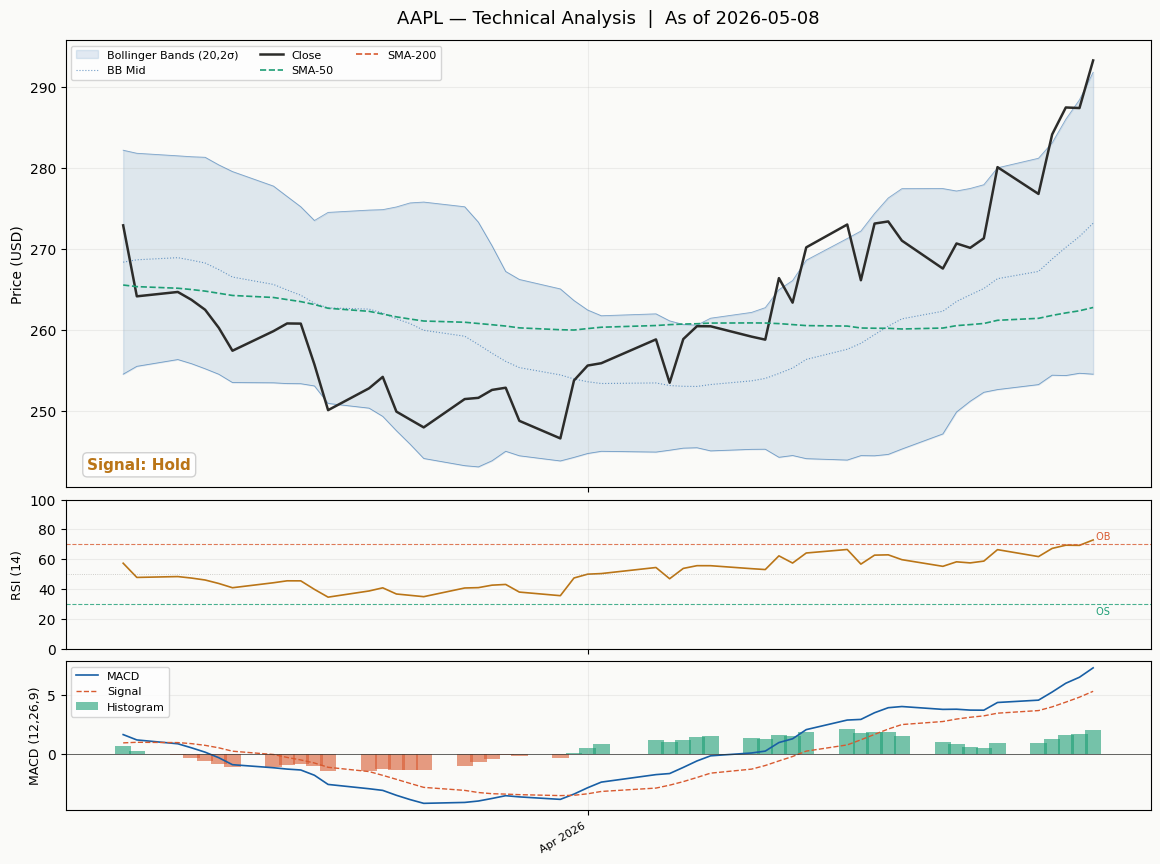

In [142]:
# ============================================================
# CELL 11 — Bonus: Chart Generation
# ============================================================
# Three-panel chart: Price+SMAs+BBands / RSI / MACD
# AI-ASSISTED: Claude (claude-sonnet-4-6), Prompt: 'Generate a 3-panel
# matplotlib chart for equity research showing price, RSI, MACD', Date: 2026-05-09

def generate_chart(df: pd.DataFrame, ticker: str, lookback_days: int = 180) -> str:
    """
    Generate a 3-panel technical analysis chart.

    Returns: path to saved PNG file.
    """
    tail = df.dropna(subset=['SMA_50']).tail(lookback_days)

    fig = plt.figure(figsize=(14, 10), facecolor='#FAFAF8')
    gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.05)

    ax1 = fig.add_subplot(gs[0])   # Price panel
    ax2 = fig.add_subplot(gs[1], sharex=ax1)   # RSI
    ax3 = fig.add_subplot(gs[2], sharex=ax1)   # MACD

    # ---- Panel 1: Price + SMAs + Bollinger Bands ----
    ax1.fill_between(
        tail.index, tail['BB_Lower'], tail['BB_Upper'],
        alpha=0.12, color='#185FA5', label='Bollinger Bands (20,2σ)'
    )
    ax1.plot(tail.index, tail['BB_Upper'], color='#185FA5', lw=0.6, alpha=0.5)
    ax1.plot(tail.index, tail['BB_Lower'], color='#185FA5', lw=0.6, alpha=0.5)
    ax1.plot(tail.index, tail['BB_Mid'],   color='#185FA5', lw=0.8, ls=':',
             alpha=0.6, label='BB Mid')
    ax1.plot(tail.index, tail['Close'],    color='#2C2C2A', lw=1.8,
             label='Close')
    ax1.plot(tail.index, tail['SMA_50'],   color='#1D9E75', lw=1.2, ls='--',
             label='SMA-50')
    ax1.plot(tail.index, tail['SMA_200'],  color='#D85A30', lw=1.2, ls='--',
             label='SMA-200')
    ax1.set_ylabel('Price (USD)', fontsize=10)
    ax1.legend(fontsize=8, loc='upper left', ncol=3)
    ax1.set_title(
        f"{ticker} — Technical Analysis  |  As of {summary['as_of_date']}",
        fontsize=13, pad=12
    )
    ax1.grid(True, alpha=0.2, linestyle='-')
    ax1.set_facecolor('#FAFAF8')

    # Add signal annotation
    signal_color = {'Buy': '#1D9E75', 'Hold': '#BA7517', 'Sell': '#D85A30'}
    ax1.annotate(
        f"Signal: {trade_signal.signal}",
        xy=(0.02, 0.04), xycoords='axes fraction',
        fontsize=11, fontweight='bold',
        color=signal_color.get(trade_signal.signal, 'black'),
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor='#ccc', alpha=0.9)
    )

    # ---- Panel 2: RSI ----
    ax2.plot(tail.index, tail['RSI_14'], color='#BA7517', lw=1.2, label='RSI (14)')
    ax2.axhline(70, color='#D85A30', ls='--', lw=0.8, alpha=0.8)
    ax2.axhline(50, color='#888780', ls=':',  lw=0.6, alpha=0.5)
    ax2.axhline(30, color='#1D9E75', ls='--', lw=0.8, alpha=0.8)
    ax2.fill_between(tail.index, 70, tail['RSI_14'],
                     where=tail['RSI_14'] >= 70, alpha=0.15, color='#D85A30')
    ax2.fill_between(tail.index, 30, tail['RSI_14'],
                     where=tail['RSI_14'] <= 30, alpha=0.15, color='#1D9E75')
    ax2.text(tail.index[-1], 72, ' OB', fontsize=7, color='#D85A30', va='bottom')
    ax2.text(tail.index[-1], 28, ' OS', fontsize=7, color='#1D9E75', va='top')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI (14)', fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.set_facecolor('#FAFAF8')

    # ---- Panel 3: MACD ----
    colors_hist = [
        '#1D9E75' if v >= 0 else '#D85A30'
        for v in tail['MACD_Hist']
    ]
    ax3.bar(tail.index, tail['MACD_Hist'],
            color=colors_hist, alpha=0.6, width=1.2, label='Histogram')
    ax3.plot(tail.index, tail['MACD'],        color='#185FA5',
             lw=1.2, label='MACD')
    ax3.plot(tail.index, tail['MACD_Signal'], color='#D85A30',
             lw=1.0, ls='--', label='Signal')
    ax3.axhline(0, color='#2C2C2A', lw=0.5)
    ax3.set_ylabel('MACD (12,26,9)', fontsize=9)
    ax3.legend(fontsize=8, loc='upper left')
    ax3.grid(True, alpha=0.2)
    ax3.set_facecolor('#FAFAF8')

    # ---- X-axis formatting (only on bottom panel) ----
    for ax in [ax1, ax2]:
        plt.setp(ax.get_xticklabels(), visible=False)

    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    plt.tight_layout()

    chart_path = 'chart_technical.png'
    plt.savefig(
        chart_path,
        dpi=150,
        bbox_inches='tight',
        facecolor='#FAFAF8'
    )

    plt.show()

    logger.info(f"✅ Chart saved: {chart_path}")

    return chart_path


chart_path = generate_chart(df, TICKER)


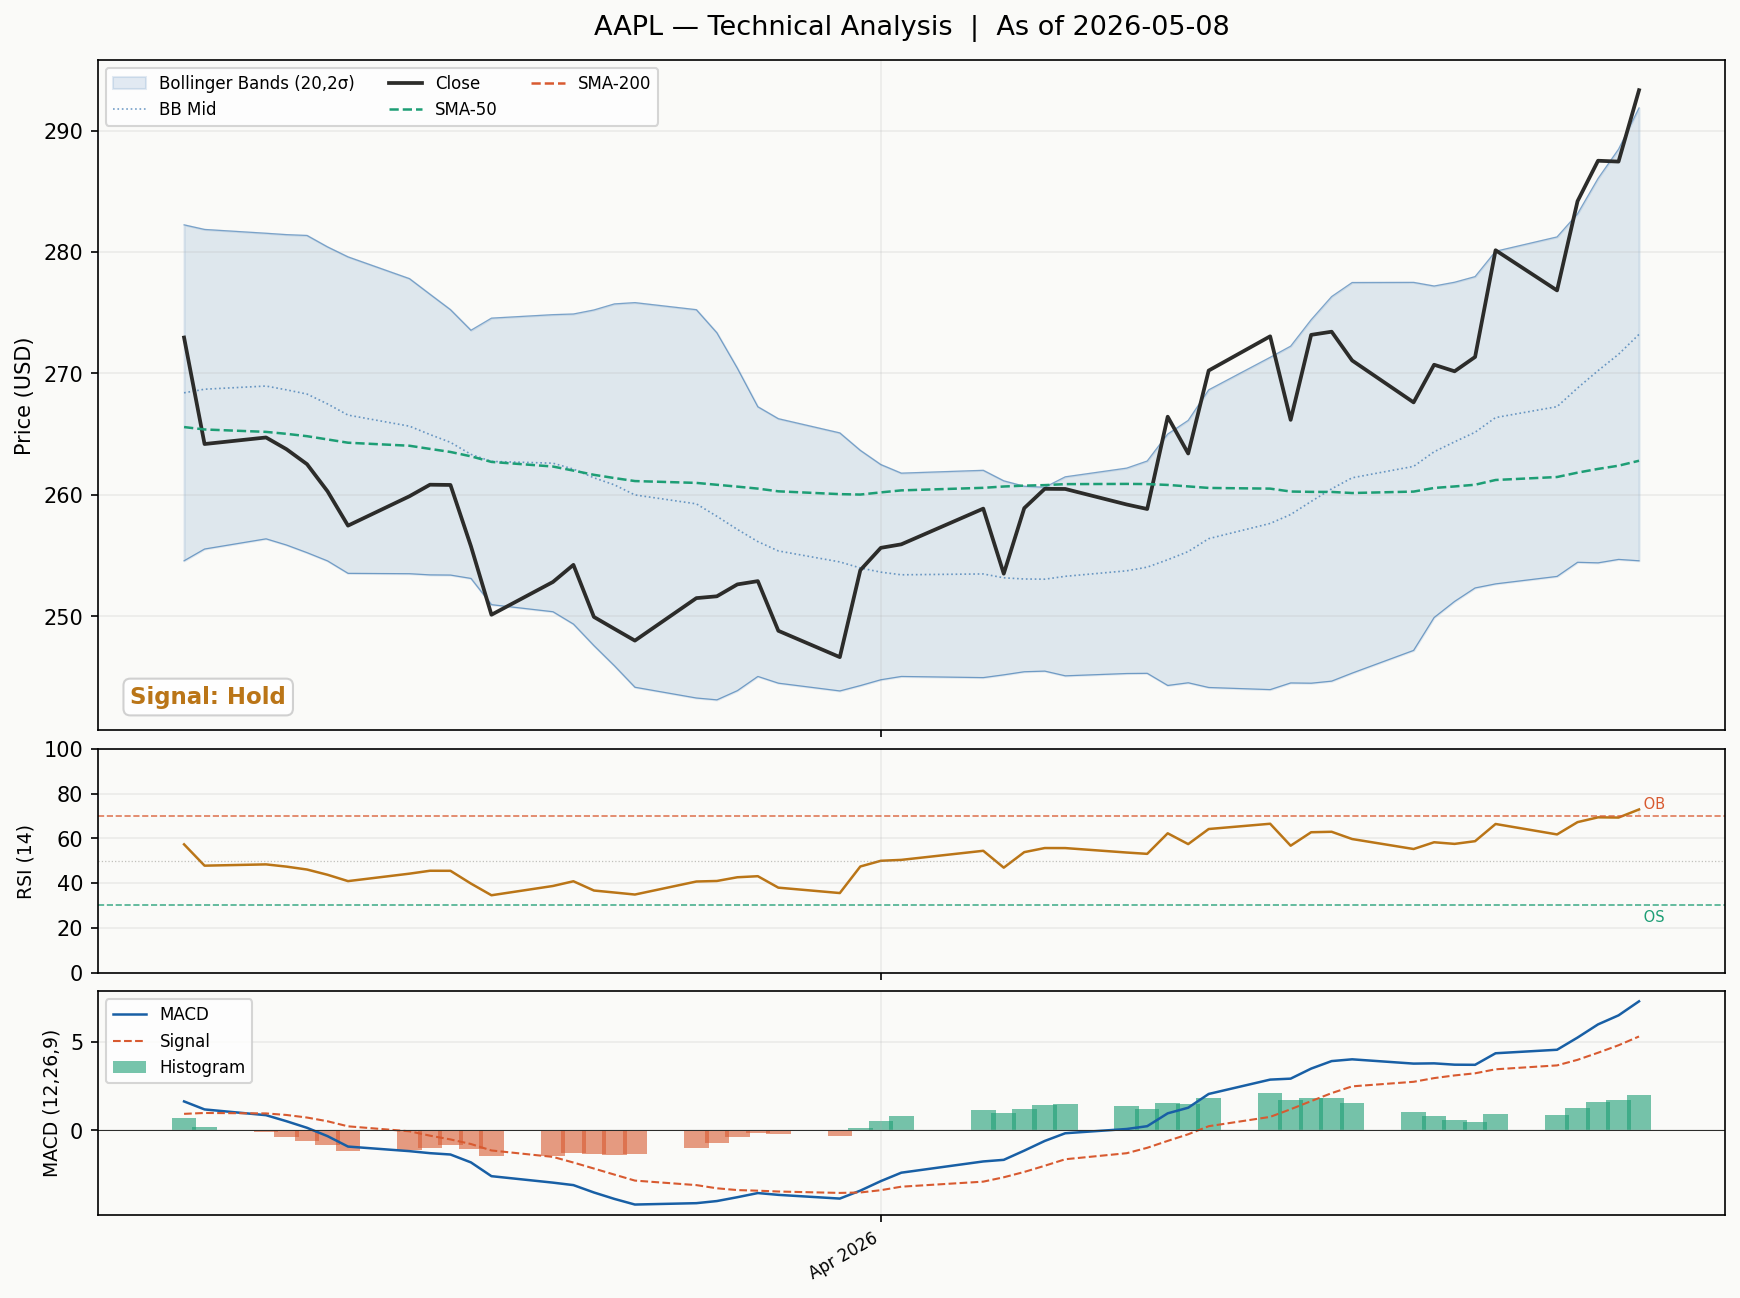


✅ Report rendered above and saved as equity_report.html


In [143]:
# ============================================================
# CELL 12 — Bonus: HTML Equity Research Report
# ============================================================
# Combines all outputs into a one-page styled equity brief.
# Renders inline in Colab and saves as HTML file.

RISK_DISCLAIMER = """
This report has been generated by an automated artificial intelligence system using
publicly available financial data sourced from Yahoo Finance and processed by the Groq
Llama-3 language model. It is provided for informational and educational purposes only
and does not constitute investment advice, a solicitation, or a recommendation to buy,
hold, or sell any security or financial instrument. Past performance is not indicative
of future results. Market data may be delayed. Technical indicators are mathematical
constructs and do not guarantee future price movements. Always consult a qualified and
licensed financial adviser before making any investment decisions. The authors accept
no liability for any financial losses arising from reliance on this report.
"""

def generate_html_report(
    summary: dict,
    sentiment_batch: SentimentBatch,
    trade_signal: TradeSignal,
    chart_path: str,
    output_file: str = 'equity_report.html'
) -> str:
    """
    Generate a complete one-page HTML equity research report.
    Embeds the chart as base64 (self-contained, no external dependencies).
    Returns the HTML string and saves to file.
    """

    # Embed chart as base64
    try:
        with open(chart_path, 'rb') as f:
            chart_b64 = base64.b64encode(f.read()).decode('utf-8')

        chart_html = (
            f"<img src='data:image/png;base64,{chart_b64}' "
            "style='width:100%;border-radius:8px;margin:16px 0'>"
        )

    except Exception as e:
        logger.warning(f"Could not embed chart: {e}")
        chart_html = (
            f"<p style='color:#888'>[Chart not available: {e}]</p>"
        )

    # Sentiment colour map
    s_colour = {
        'positive': '#1D9E75',
        'negative': '#D85A30',
        'neutral':  '#888780'
    }

    sig_colour = {
        'Buy':  '#1D9E75',
        'Hold': '#BA7517',
        'Sell': '#D85A30'
    }

    sig_bg = {
        'Buy':  '#E1F5EE',
        'Hold': '#FAEEDA',
        'Sell': '#FCEBEB'
    }

    top3_headlines = sentiment_batch.results[:3]

    headlines_html = ''.join([
        f"""
        <div style='padding:10px 0;border-bottom:1px solid #eee'>
          <span style='background:{s_colour[h.sentiment]};
            color:#fff;
            padding:2px 10px;
            border-radius:12px;
            font-size:11px;
            font-weight:600;
            text-transform:uppercase'>
            {h.sentiment}
          </span>

          <span style='margin-left:8px;
            font-size:13px;
            color:#2C2C2A'>
            {h.headline[:110]}
          </span><br>

          <span style='margin-left:55px;
            font-size:11px;
            color:#888'>
            {h.brief_reason}
          </span>
        </div>
        """
        for h in top3_headlines
    ])

    factors_html = ''.join([
        f"<li style='margin:6px 0;font-size:13px'>{fac}</li>"
        for fac in trade_signal.key_factors
    ])

    overall_sentiment_label = (
        'Bullish' if sentiment_batch.overall_score > 0.1
        else 'Bearish' if sentiment_batch.overall_score < -0.1
        else 'Neutral'
    )

    pe_display = (
        f"{summary['pe_ratio']:.1f}x"
        if summary['pe_ratio']
        else 'N/A'
    )

    html = f"""<!DOCTYPE html>
<html lang="en">

<head>
  <meta charset="UTF-8">
  <meta name="viewport"
        content="width=device-width, initial-scale=1.0">

  <title>
    {summary['ticker']} Equity Research — {summary['as_of_date']}
  </title>

  <style>

    * {{
      box-sizing: border-box;
      margin: 0;
      padding: 0;
    }}

    body {{
      font-family: Georgia, 'Times New Roman', serif;
      max-width: 960px;
      margin: 0 auto;
      padding: 40px 32px;
      color: #2C2C2A;
      background: #FAFAF8;
      line-height: 1.7;
    }}

    h1 {{
      font-size: 26px;
      font-weight: bold;
      border-bottom: 3px solid #1D9E75;
      padding-bottom: 10px;
      margin-bottom: 4px;
    }}

    h2 {{
      font-size: 16px;
      font-weight: bold;
      color: #185FA5;
      margin: 28px 0 10px;
      text-transform: uppercase;
      letter-spacing: 0.5px;
      border-left: 4px solid #185FA5;
      padding-left: 10px;
    }}

    .meta {{
      font-size: 12px;
      color: #888;
      margin-bottom: 24px;
    }}

    .grid4 {{
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 14px;
      margin: 14px 0;
    }}

    .metric {{
      background: white;
      border: 1px solid #E8E6E0;
      border-radius: 10px;
      padding: 14px 16px;
      text-align: center;
    }}

    .metric .val {{
      font-size: 24px;
      font-weight: bold;
      color: #1D9E75;
    }}

    .metric .lbl {{
      font-size: 11px;
      color: #888;
      margin-top: 4px;
      text-transform: uppercase;
      letter-spacing: 0.5px;
    }}

    .indicator-grid {{
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 10px;
      margin: 14px 0;
    }}

    .ind-card {{
      background: white;
      border: 1px solid #E8E6E0;
      border-radius: 8px;
      padding: 12px 14px;
    }}

    .ind-card .name {{
      font-size: 11px;
      color: #888;
      text-transform: uppercase;
      letter-spacing: 0.5px;
    }}

    .ind-card .val {{
      font-size: 18px;
      font-weight: bold;
      color: #2C2C2A;
    }}

    .ind-card .note {{
      font-size: 11px;
      color: #888;
      margin-top: 3px;
    }}

    .signal-box {{
      background: {sig_bg.get(trade_signal.signal, '#F1F1F1')};
      border: 2px solid {sig_colour.get(trade_signal.signal, '#888')};
      border-radius: 12px;
      padding: 20px 24px;
      margin: 14px 0;
    }}

    .signal-box .sig {{
      font-size: 36px;
      font-weight: bold;
      color: {sig_colour.get(trade_signal.signal, '#888')};
    }}

    .signal-box .conf {{
      font-size: 13px;
      color: #888;
      margin-top: 4px;
    }}

    .signal-box .just {{
      font-size: 14px;
      margin-top: 12px;
      line-height: 1.7;
      color: #2C2C2A;
    }}

    .sentiment-bar {{
      display: flex;
      height: 10px;
      border-radius: 5px;
      overflow: hidden;
      margin: 10px 0;
    }}

    .disclaimer {{
      background: #F1EFE8;
      border-left: 5px solid #888780;
      border-radius: 0 8px 8px 0;
      padding: 14px 18px;
      margin-top: 36px;
      font-size: 11px;
      color: #5F5E5A;
      line-height: 1.6;
      font-family: Arial, sans-serif;
    }}

    @media print {{
      body {{
        padding: 20px;
      }}
    }}

  </style>

</head>

<body>

<h1>{summary['ticker']} — Equity Research Brief</h1>

<p class="meta">
  Generated: {summary['as_of_date']}
  &nbsp;|&nbsp;
  Data: Yahoo Finance (yfinance)
  &nbsp;|&nbsp;
  AI: Groq {GROQ_MODEL}
  &nbsp;|&nbsp;
  Assessment: CDAZZDEV MLE Task 1
</p>

<h2>Company Snapshot</h2>

<div class="grid4">

  <div class="metric">
    <div class="val">${summary['current_price']}</div>
    <div class="lbl">Current Price</div>
  </div>

  <div class="metric">
    <div class="val">${summary['52w_high']}</div>
    <div class="lbl">52-Week High</div>
  </div>

  <div class="metric">
    <div class="val">${summary['52w_low']}</div>
    <div class="lbl">52-Week Low</div>
  </div>

  <div class="metric">
    <div class="val"
         style='color:{"#1D9E75" if summary["ytd_return_pct"] >= 0 else "#D85A30"}'>
      {summary['ytd_return_pct']:+.1f}%
    </div>
    <div class="lbl">YTD Return</div>
  </div>

  <div class="metric">
    <div class="val">{pe_display}</div>
    <div class="lbl">P/E Ratio</div>
  </div>

  <div class="metric">
    <div class="val"
         style='color:{
             "#1D9E75"
             if summary["momentum_signal"] == "bullish"
             else "#D85A30"
             if summary["momentum_signal"] == "bearish"
             else "#888"
         }'>
      {summary['momentum_signal'].upper()}
    </div>
    <div class="lbl">Momentum</div>
  </div>

  <div class="metric">
    <div class="val">{summary['data_points']:,}</div>
    <div class="lbl">Trading Days</div>
  </div>

  <div class="metric">
    <div class="val">{summary['rsi_14']}</div>
    <div class="lbl">RSI (14)</div>
  </div>

</div>

<h2>Technical Chart</h2>

{chart_html}

<h2>Technical Outlook</h2>

<div class="indicator-grid">

  <div class="ind-card">
    <div class="name">SMA-50</div>
    <div class="val">${summary['sma_50']}</div>
    <div class="note">
      Price is {
          'above ▲'
          if (summary['current_price'] or 0) > (summary['sma_50'] or 0)
          else 'below ▼'
      } short-term average
    </div>
  </div>

  <div class="ind-card">
    <div class="name">SMA-200</div>
    <div class="val">${summary['sma_200']}</div>
    <div class="note">
      {
          'Golden Cross ✅'
          if (summary['sma_50'] or 0) > (summary['sma_200'] or 0)
          else 'Death Cross ⚠️'
      }
      (SMA-50 vs SMA-200)
    </div>
  </div>

  <div class="ind-card">
    <div class="name">MACD (12,26,9)</div>
    <div class="val">{summary['macd']}</div>
    <div class="note">
      Signal: {summary['macd_signal']}
      | Hist: {summary['macd_hist']}
    </div>
  </div>

  <div class="ind-card">
    <div class="name">Bollinger Bands</div>
    <div class="val">
      ${summary['bb_upper']} / ${summary['bb_lower']}
    </div>
    <div class="note">
      Mid: ${summary['bb_mid']}
      | %B: {(summary['bb_pct_b'] or 0) * 100:.1f}%
    </div>
  </div>

</div>

<h2>News Sentiment Summary</h2>

<p style='font-size:13px;margin-bottom:10px'>
  Overall sentiment score:
  <strong>{sentiment_batch.overall_score:+.3f}</strong>
  — <strong>{overall_sentiment_label}</strong>
  &nbsp;(
  {sentiment_batch.positive_count} positive,
  {sentiment_batch.negative_count} negative,
  {sentiment_batch.neutral_count} neutral
  )
</p>

<div class="sentiment-bar">
  <div style='flex:{sentiment_batch.positive_count};background:#1D9E75'></div>
  <div style='flex:{sentiment_batch.neutral_count};background:#D3D1C7'></div>
  <div style='flex:{sentiment_batch.negative_count};background:#D85A30'></div>
</div>

<p style='font-size:12px;color:#888;margin-bottom:12px'>
  Top 3 headlines:
</p>

{headlines_html}

<h2>LLM Recommendation</h2>

<div class="signal-box">

  <div class="sig">{trade_signal.signal}</div>

  <div class="conf">
    Confidence: {trade_signal.confidence:.0%}
    &nbsp;|&nbsp;
    Risk Level: {trade_signal.risk_level}
  </div>

  <div class="just">
    {trade_signal.justification}
  </div>

</div>

<p style='font-size:13px;font-weight:bold;margin-bottom:6px'>
  Key Factors:
</p>

<ul style='margin-left:20px'>
  {factors_html}
</ul>

<div class="disclaimer">

  <strong>⚠️ Risk Disclaimer</strong><br>

  {RISK_DISCLAIMER.strip()}

</div>

</body>
</html>
"""

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html)

    logger.info(f"✅ HTML report saved: {output_file}")

    return html


# --- Run it ---
html_output = generate_html_report(
    summary,
    sentiment_batch,
    trade_signal,
    chart_path,
    output_file='equity_report.html'
)

# Render inline in Colab
display(HTML(html_output))

print("\n✅ Report rendered above and saved as equity_report.html")

Step 13 — Full Pipeline Summary (Final cell)

In [144]:
# STEP 13 — Full Pipeline Runner Summary

print("=" * 60)
print("   CDAZZDEV MLE — Task 1 Complete Pipeline Summary")
print("=" * 60)

print(f"""
TASK 1A — Financial Data Pipeline
----------------------------------
✅ Ticker:         {summary['ticker']}
✅ Data points:    {summary['data_points']:,} trading days ({PERIOD})
✅ As of date:     {summary['as_of_date']}

Price Snapshot:
   Current Price:   ${summary['current_price']}
   52-Week High:    ${summary['52w_high']}
   52-Week Low:     ${summary['52w_low']}
   P/E Ratio:       {summary['pe_ratio'] or 'N/A'}
   YTD Return:      {summary['ytd_return_pct']:+.2f}%

Indicators (latest values):
   SMA-50:          ${summary['sma_50']}
   SMA-200:         ${summary['sma_200']}
   RSI-14:          {summary['rsi_14']}
   MACD:            {summary['macd']}  |  Signal: {summary['macd_signal']}
   Bollinger Upper: ${summary['bb_upper']}
   Bollinger Lower: ${summary['bb_lower']}

✅ Momentum Signal: {summary['momentum_signal'].upper()}
✅ News Headlines:  {len(news)} retrieved
""")

print(f"""TASK 1B — LLM Reasoning
----------------------------------
✅ Sentiment analysed:  {sentiment_batch.total_headlines} headlines
   Positive:           {sentiment_batch.positive_count}
   Negative:           {sentiment_batch.negative_count}
   Neutral:            {sentiment_batch.neutral_count}
   Overall Score:      {sentiment_batch.overall_score:+.4f}

✅ Trade Signal:        {trade_signal.signal}
   Confidence:         {trade_signal.confidence:.0%}
   Risk Level:         {trade_signal.risk_level}

BONUS
----------------------------------
✅ Chart:              chart_technical.png
✅ HTML Report:        equity_report.html
""")
print("=" * 60)
print("   ALL TASKS COMPLETE")
print("=" * 60)

   CDAZZDEV MLE — Task 1 Complete Pipeline Summary

TASK 1A — Financial Data Pipeline
----------------------------------
✅ Ticker:         AAPL
✅ Data points:    100 trading days (2y)
✅ As of date:     2026-05-08

Price Snapshot:
   Current Price:   $293.32
   52-Week High:    $294.76
   52-Week Low:     $243.42
   P/E Ratio:       35.47
   YTD Return:      +8.23%

Indicators (latest values):
   SMA-50:          $262.8
   SMA-200:         $None
   RSI-14:          72.95
   MACD:            7.299  |  Signal: 5.3091
   Bollinger Upper: $291.86
   Bollinger Lower: $254.56

✅ Momentum Signal: BULLISH
✅ News Headlines:  15 retrieved

TASK 1B — LLM Reasoning
----------------------------------
✅ Sentiment analysed:  15 headlines
   Positive:           5
   Negative:           3
   Neutral:            7
   Overall Score:      +0.1000

✅ Trade Signal:        Hold
   Confidence:         60%
   Risk Level:         Medium

BONUS
----------------------------------
✅ Chart:              chart_techni